## Libraries and Packages

In [1]:
## conda env (kernel): faiss_py10

import torch
import torch.nn as nn

import faiss
import numpy as np

import albumentations as A
from albumentations.pytorch import ToTensorV2
import glob 
from tqdm import tqdm 
import matplotlib.pyplot as plt 
import os 


from huggingface_hub import hf_hub_download
import torch
import torch.nn as nn

# download class module file to local directory
hf_hub_download("MVRL/satmaepp_ViT-L_pretrain_fmow_rgb", "model.py", local_dir="satmae_model")

from satmae_model.model import MaskedAutoencoderViT

import warnings
warnings.filterwarnings("ignore")

/home/guoj5/anaconda3/envs/faiss_py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guoj5/anaconda3/envs/faiss_py10/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Setup (Define Here)

In [2]:
pretrained_weight = 'MVRL/satmaepp_ViT-L_pretrain_fmow_rgb'            # Path to pre-trained checkpoint
device = torch.device("cuda:0")                                        # Specify GPU index 
path_to_all_images = '/data/guoj5/testing1/*.npy'                      # Path to all database images
number_to_retrieve = 10                                                # Top-k retrieval ranked by cosine similarity

query_image_path = '/data/guoj5/testing1/CLS1-7760-223.npy'            # A query image for retrieval


# image to embedding help func
def extract_features(image_path, model, transform):
    """Extract image features using the provided model."""
    image = np.load(image_path)
    input_tensor = transform(image=image)['image'].unsqueeze(0) # unsqueeze when batch size 1 
    
    # torch uint8 -> torch.float32
    if input_tensor.dtype == torch.uint8:
        input_tensor = input_tensor.float() / 255.0  # Convert to float and normalize

    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        features = model.forward_encoder(input_tensor, mask_ratio=0.0)[0][:,0,:] # (1, 1024)
    return features.cpu().detach().numpy().squeeze()


def adapt_patch_embed_in_chans(model, new_in_ch=8, mode="repeat_scaled"):
    """
    Make model.patch_embed.proj accept `new_in_ch` by inflating pretrained RGB weights.
    mode:
      - 'repeat_scaled': repeat RGB across bands and scale by (3 / new_in_ch)
      - 'mean': average RGB, copy to all bands
    """
    pe = model.patch_embed.proj                      # Conv2d [E, 3, p, p]
    W = pe.weight.data
    E, old_in, p1, p2 = W.shape
    assert old_in == 3, f"Expected 3 input channels, got {old_in}"

    if mode == "mean":
        W_new = W.mean(dim=1, keepdim=True).repeat(1, new_in_ch, 1, 1)
    elif mode == "repeat_scaled":
        reps = (new_in_ch + old_in - 1) // old_in
        W_new = W.repeat(1, reps, 1, 1)[:, :new_in_ch, :, :]
        W_new *= (old_in / float(new_in_ch))  # preserve variance roughly
    else:
        raise ValueError("mode must be 'repeat_scaled' or 'mean'")

    new_conv = nn.Conv2d(
        in_channels=new_in_ch, out_channels=E,
        kernel_size=(p1, p2), stride=pe.stride,
        padding=pe.padding, dilation=pe.dilation,
        groups=pe.groups, bias=(pe.bias is not None)
    )
    new_conv.weight = nn.Parameter(W_new)
    if pe.bias is not None:
        new_conv.bias = nn.Parameter(pe.bias.data.clone())

    model.patch_embed.proj = new_conv
    if hasattr(model.patch_embed, "in_chans"):
        model.patch_embed.in_chans = new_in_ch
    return model


## Load pre-trained backbone

In [3]:
model = MaskedAutoencoderViT.from_pretrained(pretrained_weight)

# Adapt patch embed to 8-channel input
adapt_patch_embed_in_chans(model, new_in_ch=8, mode="mean")
model.eval()

MaskedAutoencoderViT(
  (proj_up_conv): Conv2d(3, 12, kernel_size=(1, 1), stride=(1, 1))
  (proj_up_norm): LayerNorm()
  (up_block): UpsampleBlock(
    (up_conv): ConvTranspose2d(12, 12, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (up_norm): LayerNorm()
    (res_block): ResidualBlock(
      (conv1): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
    )
    (res_norm): LayerNorm()
    (proj_out): Conv2d(12, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (patch_embed): PatchEmbed(
    (proj): Conv2d(8, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
       

## Create faiss index database

In [4]:
 # 1. Move the model to GPU
model = model.to(device)        


# 2. Define a Transformation Pipeline for Images
resize_transform = A.Compose([
    A.Resize(224, 224),     # Target size (H, W)
    ToTensorV2()            # Converts to PyTorch tensor
])


# 3. Create a Dataset of Image Features
image_paths = glob.glob(path_to_all_images)

features = [extract_features(img, model, resize_transform) for img in tqdm(image_paths, desc="FAISS ID CREATE:")]
features = np.array(features).astype('float32')  # Convert to float32 (required by FAISS)

# 4. Normalize the Features (Required for Cosine Similarity)
features_normalized = features / np.linalg.norm(features, axis=1, keepdims=True)

# 5. Create a FAISS Index for Inner Product (Cosine Similarity)
dimension = features_normalized.shape[1]     # Dimension of the feature vectors
index = faiss.IndexFlatIP(dimension)         # Inner product index
index.add(features_normalized)               # Add normalized features to the index

print(f"Number of images indexed: {index.ntotal}")

FAISS ID CREATE:: 100%|██████████| 8019/8019 [01:17<00:00, 103.94it/s]


Number of images indexed: 8019


## Query image

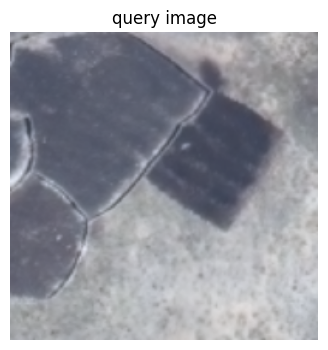

In [5]:
query_feature = extract_features(query_image_path, model, resize_transform).astype('float32')
query_feature_normalized = query_feature / np.linalg.norm(query_feature)  # Normalize query

plt.figure(figsize=(4,4))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()

## Retrieve Top-k images from database

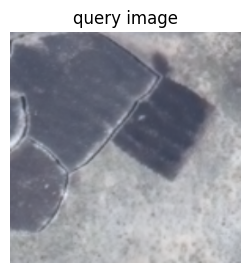

Top 10 similar images


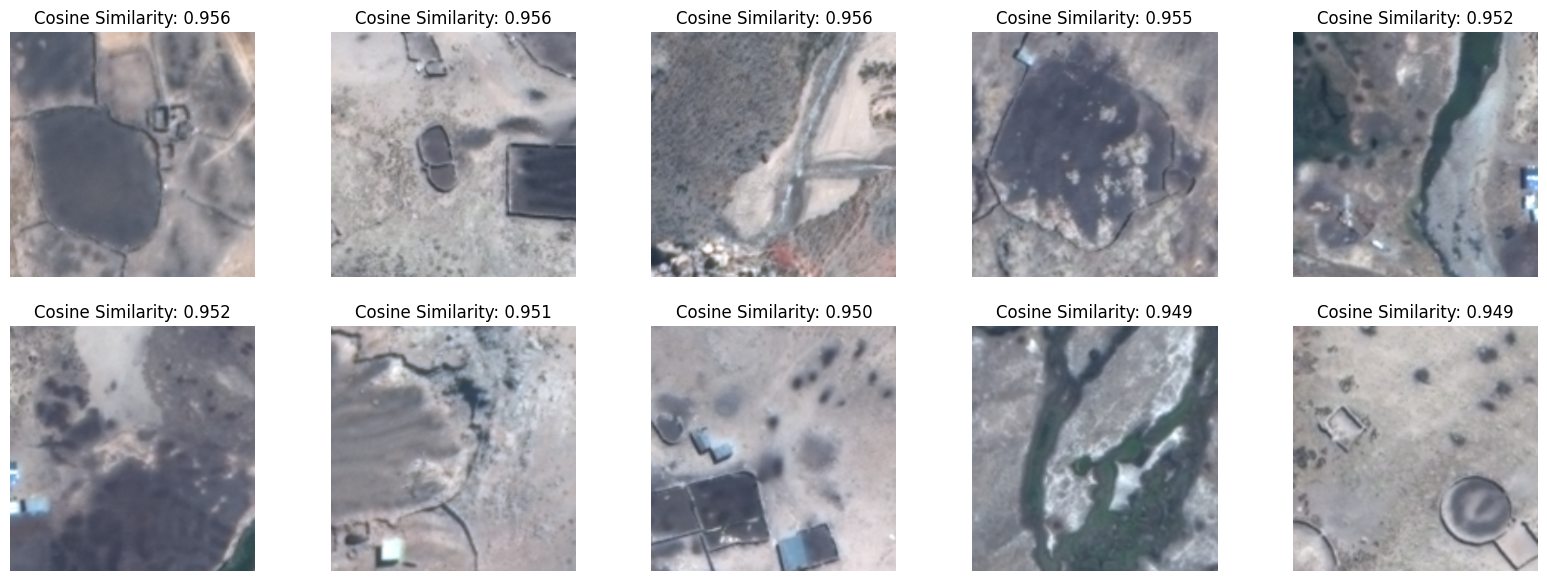

In [6]:
 #  number_to_retrieve + 1 of similar images to retrieve (including the query Image itself)
distances, indices = index.search(np.expand_dims(query_feature_normalized, axis=0), number_to_retrieve + 1)


# 7. Display Results

# dispaly query image input 
plt.figure(figsize=(3,3))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()


# display retrieved top-k images (k =10 means number_to_retrieve = 10)
print(f'Top {number_to_retrieve} similar images')
fig, axes = plt.subplots(2, 5, figsize=(20, 7))  # Adjust col number based on k (number_to_retrieve)
count = 0 
for idx, dist in zip(indices[0][1::], distances[0][1::]):
    # Load and display the image using channels 4, 2, and 1 as RGB for visualization purposes only
    img = np.load(image_paths[idx])[:, :, (4, 2, 1)]
    axes[count//5][count % 5].imshow(img)
    axes[count//5][count % 5].set_title(f'Cosine Similarity: {dist:.3f}')
    axes[count//5][count % 5].axis('off')  
    count +=1 